# Activity: Bellman-Ford Shortest Path Algorithm
This activity will introduce you to [the Bellman-Ford algorithm](https://en.wikipedia.org/wiki/Bellman–Ford_algorithm) for finding the shortest path from a single source vertex to all other vertices in a weighted graph. 

The [Bellman-Ford algorithm](https://en.wikipedia.org/wiki/Bellman–Ford_algorithm) is a graph search algorithm that can search graphs with negative edge weights. However, it is slower than Dijkstra's algorithm. Bellman-Ford has a time complexity of $\mathcal{O}(|\mathcal{V}|\cdot|\mathcal{E}|)$, where $|\mathcal{V}|$ is the number of vertices and $|\mathcal{E}|$ is the number of edges in the graph.

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [1]:
include("Include.jl");

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

### Constants
Let's define some constants that will be used throughout the notebook. See the comment for a description of each constant, what it represents, its value, units, etc.

In [2]:
# We are going to plot the path through a graph, so let's provide the coordinates for each node, i.e., the layout
# This layout looks like our schematic but you can rearrange this if you want!
node_coordinates = [

    # source nde (you)
    10.0 10.0 ; # 1 source node s (x,y) coordinates

    # people nodes (workers)
    11.0 11.0 ; # 2 people node (x,y) coordinates
    11.0 10.0 ; # 3 people node (x,y) coordinates
    11.0 9.0 ; # 4 people node (x,y) coordinates

    # job nodes (tasks)
    12.0 11.0 ; # 5 job node (x,y) coordinates
    12.0 10.0 ; # 6 job node (x,y) coordinates
    12.0 9.0 ; # 7 job node (x,y) coordinates

    # sink nodes (targets, tasks done!)
    13.0 11.0 ; # 8 sink node t (x,y) coordinates
    13.0 10.0 ; # 9 sink node t (x,y) coordinates
    13.0 9.0 ; # 10 sink node t (x,y) coordinates
];

### Implementations
Let's define some helper functions that we'll use in the notebook. The `flow(...)` function will help us visualize the flow of the algorithm. It takes a graph model instance, the distances and predecessors, and then computes the flow at each __node__, i.e., if a node $i$ is included on a path from the source to the sink, it will have a non-zero flow.

In [3]:
"""
    function flow(graph::MySimpleDirectedGraphModel, distances::Dict{Int64, Float64}, 
        previous::Dict{Int64, Union{Nothing,Int64}})::Array{Float64,1}

Computes the flow through the graph based on the shortest path tree defined by `distances` and `previous`.

### Arguments
- `graph`: The graph model instance.
- `distances`: A dictionary mapping each node to its distance from the source.
- `previous`: A dictionary mapping each node to its predecessor in the shortest path tree.

### Returns
- An array representing the flow through the graph.
"""
function flow(graph::MySimpleDirectedGraphModel, distances::Dict{Int64, Float64}, 
    previous::Dict{Int64, Union{Nothing,Int64}})::Array{Float64,1}
    
    # initialize -
    number_of_nodes = length(graph.nodes);
    number_of_edges = length(graph.edges);
    flow = zeros(Float64, number_of_edges); # initialize the flow array with zeros

    # create a inverse edge dictionary -
    inversedgemap = Dict{Tuple{Int64, Int64}, Int64}();
    for (k, v) ∈ graph.edgesinverse
        inversedgemap[v] = k;
    end

    # iterate over the edges -
    nodes = range(2, stop=number_of_nodes) |> collect |> reverse;
    for node ∈ nodes
        p = previous[node]; # this is a connection
        i = inversedgemap[(p, node)]; # this is the edge id
        flow[i] = 1.0;
    end

    # return -
    return flow;
end;

___

## Task 1: Let's build a task allocation model
Imagine you (node `1`) are in charge of allocating workers to tasks, i.e., faculty to courses, widgets to machines, etc. You have a list of workers and a list of tasks that need to get done. While each worker can perform each task, they have a preference for each task reflected in the edge weight connecting workers to tasks.

> __Structure:__ The weight of the edge connecting worker `i` to task `j` is the cost of assigning worker `i` to task `j.` If $w_{ij} < 0$, it means that worker `i` prefers task `j`. If $w_{ij} > 0$, it means that worker `i` dislikes task `j`. If $w_{ij} = 0$, it means that worker `i` is indifferent to task `j.` At most, one worker can be assigned to each task.

This idea is represented in the schematic below:

<div>
    <center>
        <img src="figs/Fig-BalancedSchematic-PeopleTasks-Problem.svg" width="480"/>
    </center>
</div>

We want to assign workers to tasks in a way that __minimizes the cost__ of the assignment. The graph and weights are specified in the `data/Balanced-Bipartite.edgelist` file, where each record is defined as:
> __Records__: Each record in our edgelist file has the comma separated fields: `source,` `target,` `cost,` `lb capacity,` `ub capacity`. The `source` field is the id for the source node, e.g., `1`, the `target` field is the target node id, the `cost` is the cost of assigning the source node to the target node, the `lb capacity` is the lower bound capacity for the edge, and the `ub capacity` is the upper bound capacity for the edge.

In this case study, we'll ignore the capacity constraints, but these will become important a few modules down the road, so hang tight! Ok, so now let's setup our edge parser __callback function__:

In [4]:
"""
    function edgerecordparser(record::String, delim::Char=',') -> Tuple{Int, Int, Float64} | Nothing

This method is called to parse a single edge record from the edgelist file. It gets called once for each record in the file. 
The function splits the record into fields based on the specified delimiter and extracts the source node, target node, and cost (weight) of the edge. 
It returns a tuple containing these values. If the record does not have the expected number of fields, it returns `nothing`.

### Arguments
- `record`: The edge record string to parse.
- `delim`: The delimiter used to split the record.

### Returns
- A tuple containing the source node, target node, and cost of the edge, or `nothing` if the record is invalid.
"""
function edgerecordparser(record::String, delim::Char=',')
    
    # record (five fields)
    # source, target, cost, lb, ub

    fields = split(record, delim) # this assumes a record of the form "source,target,weight"
    if length(fields) < 5 # we have 5 fields
        return nothing
    end

    # get my data -
    source = parse(Int, fields[1]) # source id
    target = parse(Int, fields[2]) # target id
    cost = parse(Float64, fields[3]) # edge weight
    
    # return a tuple -
    return (source, target, cost) # we are ignoring the capacity constraints
end;

Next, let's set the path to the edge list file in the `path_to_edge_file::String` variable:

In [5]:
path_to_edge_file = joinpath(_PATH_TO_DATA, "Balanced-Bipartite.edgelist"); # this points to the graph shown above

Next, construct a dictionary [of `MyEdgeModel` instances](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MyGraphEdgeModel) which stores the data for the edges. Let's save our edge models in the `myedgemodels::Dict{Int64, MyGraphEdgeModel}` dictionary. 

The keys in the edge dictionary will be the edge ids (which we can assume are unique), and the values will be the corresponding `MyGraphEdgeModel` instances. Here, we've used the line index in the edgefile as the edge id.

In [6]:
myedgemodels = MyGraphEdgeModels(path_to_edge_file, edgerecordparser, delim=',', comment='#')

Dict{Int64, MyGraphEdgeModel} with 15 entries:
  5  => MyGraphEdgeModel(5, 7, 10, 0.0)
  12 => MyGraphEdgeModel(12, 4, 5, 1.0)
  8  => MyGraphEdgeModel(8, 2, 7, 1.0)
  1  => MyGraphEdgeModel(1, 1, 3, 0.0)
  0  => MyGraphEdgeModel(0, 1, 2, 0.0)
  6  => MyGraphEdgeModel(6, 2, 5, 1.0)
  11 => MyGraphEdgeModel(11, 3, 7, -1.0)
  9  => MyGraphEdgeModel(9, 3, 5, 0.0)
  14 => MyGraphEdgeModel(14, 4, 7, -2.5)
  3  => MyGraphEdgeModel(3, 5, 8, 0.0)
  7  => MyGraphEdgeModel(7, 2, 6, 0.0)
  4  => MyGraphEdgeModel(4, 6, 9, 0.0)
  13 => MyGraphEdgeModel(13, 4, 6, 1.0)
  2  => MyGraphEdgeModel(2, 1, 4, 0.0)
  10 => MyGraphEdgeModel(10, 3, 6, 1.0)

### What's our edge model tell us?
The entries in our edge model dictionary, and particulary the weight fields, give us insight into the preferences of the workers for the tasks. By analyzing the weights, we can identify which tasks are more desirable for each worker, and vice versa.

For example, consider edge(s) `11` and `14`. Edge `11` describe the preferences of worker `3` for task `7`, while edge `14` describes the preferences of worker `4` for task `7`. Thus, by comparing $w_{37}$ and $w_{47}$, we can determine which worker prefers the task more.

In [7]:
let

    # initialize -
    edge_model_11 = myedgemodels[11]; # this is the edge model for edge 11
    edge_model_14 = myedgemodels[14]; # this is the edge model for edge 14

    w37 = edge_model_11.weight; # this is the weight for edge 11
    w47 = edge_model_14.weight; # this is the weight for edge 14

    if min(w37, w47) == w37
        println("Worker 3 prefers task 7 over worker 4"); # Worker 3's preference is stronger
    else
        println("Worker 4 prefers task 7 over worker 3"); # Worker 4's preference is stronger
    end
end

Worker 4 prefers task 7 over worker 3


We could also create a weight matrix to represent the preferences of all workers for all tasks. This matrix could be used to quickly identify the most preferred task for each worker, as well as to analyze the overall distribution of preferences across workers.

> __Weight matrix:__ The weight matrix $\mathbf{W}\in\mathbb{R}^{n\times{n}}$, where $n$ is the number of nodes in the graph. Thus, $w_{ij}\in\mathbf{W}$ is the weight of the edge from node $i$ to node $j$. Most of the elements in $\mathbf{W}$ will be zero because our graph is sparse. A value of $w_{ij} = 0$ indicates __either__ no connection, or no preference between node $i$ and $j$, while $w_{ij}>0$ indicates dislike, and $w_{ij}<0$ indicates like.

We'll save the weight matrix $\mathbf{W}$ in the `W::Array{Float64,2}` variable:

In [ ]:
W = let

    # build a node set from the edgemodels -
    nodes = Set{Int64}();
    for (k,v) ∈ myedgemodels
        push!(nodes, v.source);
        push!(nodes, v.target);
    end
    nodes_array = nodes |> collect |> sort;

    # create an edges dictionary -
    edges = Dict{Tuple{Int64, Int64}, Float64}();
    for (k, v) ∈ myedgemodels
        edges[(v.source, v.target)] = v.weight;
    end

    # initialize -
    n = nodes_array |> length;
    W = zeros(Float64, n, n); # this is the weight matrix

    for i ∈ 1:n
        row_index = nodes_array[i]; # this is the row index
        for j ∈ 1:n
            col_index = nodes_array[j]; # this is the column index

            # do we have an edge (row_index, col_index)?
            if haskey(edges, (row_index, col_index)) == true
                W[i,j] = edges[(row_index, col_index)];
            end

        end
    end
    W;
end

10×10 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0   1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  -1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  1.0  -2.5  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0

If we look at columns $5,6,7$ (which correspond to the task nodes) we can get a sense of how desirable a particular task is. For example, if we sum each task column, we can rank each task on the basis of its desirability:

In [ ]:
let

    # initialize -
    task_columns = [5,6,7];
    desirability_scores = zeros(Float64, length(task_columns));

    for (idx, col) ∈ enumerate(task_columns)
        desirability_scores[idx] = sum(W[:, col]); # sum the column
    end

    # rank tasks by desirability
    ranked_tasks = sortperm(desirability_scores, rev=false);
    println("Task ranking based on desirability (from most to least desirable): $(task_columns[ranked_tasks])");
end

Task ranking based on desirability (from most to least desirable): [7, 5, 6]


Finally, we can build a graph instance. Since this is a directed graph, we'll construct [a `MySimpleDirectedGraphModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MySimpleDirectedGraphModel) using [a `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build). Let's save our graph model in the `directedgraphmodel::MySimpleDirectedGraphModel` variable.

In [9]:
directedgraphmodel = build(MySimpleDirectedGraphModel, myedgemodels)

MySimpleDirectedGraphModel(Dict{Int64, MyGraphNodeModel}(5 => MyGraphNodeModel(5, nothing), 4 => MyGraphNodeModel(4, nothing), 6 => MyGraphNodeModel(6, nothing), 7 => MyGraphNodeModel(7, nothing), 2 => MyGraphNodeModel(2, nothing), 10 => MyGraphNodeModel(10, nothing), 9 => MyGraphNodeModel(9, nothing), 8 => MyGraphNodeModel(8, nothing), 3 => MyGraphNodeModel(3, nothing), 1 => MyGraphNodeModel(1, nothing)…), Dict{Tuple{Int64, Int64}, Number}((4, 5) => 1.0, (1, 2) => 0.0, (2, 5) => 1.0, (3, 7) => -1.0, (1, 3) => 0.0, (4, 6) => 1.0, (1, 4) => 0.0, (2, 6) => 0.0, (7, 10) => 0.0, (4, 7) => -2.5…), Dict{Int64, Set{Int64}}(5 => Set([8]), 4 => Set([5, 6, 7]), 6 => Set([9]), 7 => Set([10]), 2 => Set([5, 6, 7]), 10 => Set(), 9 => Set(), 8 => Set(), 3 => Set([5, 6, 7]), 1 => Set([4, 2, 3])…), Dict(5 => (2, 6), 12 => (4, 7), 8 => (3, 6), 1 => (1, 2), 6 => (2, 7), 11 => (4, 6), 9 => (3, 7), 14 => (6, 9), 3 => (1, 4), 7 => (3, 5)…))

## Task 2: Compute the best assingment
In this task, we'll compute the best assignment of workers to tasks, e.g., the shortest path from the source node (you) to the sink nodes (tasks done) using the Bellman-Ford algorithm.

This is a simple test case, so we can look at the edge weights and guess the shortest paths using our intuition, without running the algorithm. Let's do that so we can check if what we think should happen, actually happens.

> __Intuition:__ Suppose we specify a task node $j$. Then, the cost of having person $i$ assigned to task $j$ is just the edge weight $w_{ij}$. 

Let's implement this intution, and compute what we think should happen.

In [11]:
# run the Bellman Ford Algorithm algorithm -
(d,p) = findshortestpath(directedgraphmodel, directedgraphmodel.nodes[1], BellmanFordAlgorithm());

In [12]:
p

Dict{Int64, Union{Nothing, Int64}} with 10 entries:
  5  => 3
  4  => 1
  6  => 2
  7  => 4
  2  => 1
  10 => 7
  9  => 6
  8  => 5
  3  => 1
  1  => nothing

In [13]:
f = flow(directedgraphmodel, d, p);

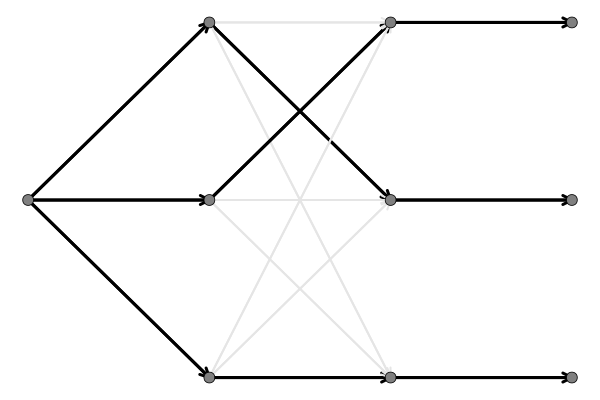

In [14]:
let

    base_graphmodel = directedgraphmodel;

    # setup coordinates for the nodes -
    # these coordinates are for the balanced example -
    q = plot();
    for (k,v) ∈ base_graphmodel.edgesinverse

        # get the flow value from the solution for this edge index -
        flow_value = f[k];
        
        # now, get the source,target node index for this edge
        s = v[1];
        t = v[2];

        # plot -
        if (flow_value != 0.0)
            plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:black, lw=3, label="")
        else
            plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:gray90, lw=2, label="")
        end
    end
    scatter!(node_coordinates[:,1], node_coordinates[:,2], axis=nothing, border=:none, label="", c=:gray, ms=6)
    current()
end